# totalVI denoising and differential expression analysis

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
import muon as mu
import scanpy as sc
import torch
import scvi
from sklearn_ann.kneighbors.annoy import AnnoyTransformer

np.random.seed(42)
scvi.settings.seed = 42
torch.set_float32_matmul_precision("high")

Seed set to 42


In [2]:
scvi.__version__

'1.2.0'

In [ ]:
results_dir = "../data/processed/cite_seq/cohort_treatment_naive/models/totalvi"
os.makedirs(results_dir, exist_ok=True)

# Load data

AnnData objects generated by running notebooks in `03_annotate`

In [8]:
adata_rna = sc.read_h5ad("../data/processed/cite_seq/cohort_treatment_naive/cellbender/annotated/annotated_rna.h5ad")
adata_adt = sc.read_h5ad("../data/processed/cite_seq/cohort_treatment_naive/cellbender/annotated/annotated_adt.h5ad")
adata_rna.X = adata_rna.X.tocsr()
adata_adt.X = adata_adt.X.tocsr()

In [9]:
hvg = adata_rna.var["var.features"].dropna().tolist()

In [ ]:
mdata = mu.MuData({"rna": adata_rna[:, hvg].copy(), "adt": adata_adt.copy()})

/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/python3.11/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [6]:
adata = adata_rna[:, hvg].copy()

adata.obsm["adt"] = pd.DataFrame(
    adata_adt.X.toarray(),
    index=adata_adt.obs_names,
    columns=adata_adt.var_names
)

In [11]:
del adata_rna, adata_adt

# Setup AnnData for TotalVI

In [8]:
scvi.model.TOTALVI.setup_anndata(
    adata,
    protein_expression_obsm_key="adt",
    batch_key="donor", # use donor as batch key as this represents the major source of nuisance variation in the dataset and needs to be corrected in the denoised normalised expression values
    categorical_covariate_keys=["sample_id", "chemistry"], # these covariates are linked to the batch key (i.e. samples are nested within donors, and all samples from a donor were processed with the same chemistry)
    continuous_covariate_keys=["pctMito_RNA", "S.Score", "G2M.Score"], # these covariates are per-cell and therefore not linked to the batch key, but represent technical and biological sources of nuisance variation
)

INFO     Using column names from columns of adata.obsm['adt']                                                      
INFO     Found batches with missing protein expression                                                             
INFO     Found batches with missing protein expression                                                             


# Setup and train totalVI model

### Setup model

In [9]:
model = scvi.model.TOTALVI(adata, n_latent=50, empirical_protein_background_prior=True)

INFO     Computing empirical prior initialization for protein background.                                          


/tmp/ipykernel_3154158/2053147788.py:1: UserWarning: Some proteins have all 0 counts in some batches. These proteins will be treated as missing measurements; however, this can occur due to experimental design/biology. Reinitialize the model with `override_missing_proteins=True`,to override this behavior.
  model = scvi.model.TOTALVI(adata, n_latent=50, empirical_protein_background_prior=True)


### Train model

In [10]:
model.train(max_epochs=200)

/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/p ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/p ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/project/fuggerlab/rfarooq/.conda/env

Training:   0%|          | 0/200 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


In [11]:
model.save(results_dir, save_anndata=True, overwrite=True)

In [6]:
model

TotalVI Model with the following params: 
n_latent: 50, gene_dispersion: gene, protein_dispersion: protein, gene_likelihood: nb, latent_distribution: normal
Training status: Trained

### Check model convergence

/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: In a future version, DataFrame.min(axis=None) will return a scalar min over the entire DataFrame. To retain the old behavior, use 'frame.min(axis=0)' or just 'frame.min()'
  return reduction(axis=axis, out=out, **passkwargs)
/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: In a future version, DataFrame.min(axis=None) will return a scalar min over the entire DataFrame. To retain the old behavior, use 'frame.min(axis=0)' or just 'frame.min()'
  return reduction(axis=axis, out=out, **passkwargs)
/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: In a future version, DataFrame.max(axis=None) will return a scalar max over the entire DataFrame. To retain the old behavior, use 'frame.max(axis=0)' or just 'frame.max()'
  return reduct

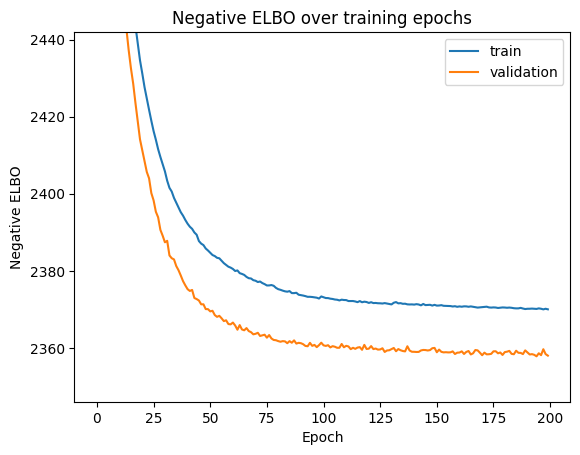

In [ ]:
last_val_valid = np.array(model.history["elbo_validation"])[-1]
last_val_train = np.array(model.history["elbo_train"])[-1]
global_min_loss = min(
    np.min(model.history["elbo_train"])[0], np.min(model.history["elbo_validation"])[0]
)
last_max_loss = max(last_val_train, last_val_valid)[0]
global_max_loss = max(
    np.max(model.history["elbo_train"])[0], np.max(model.history["elbo_validation"])[0]
)

# Automatically determine y-limits for the plot
min_loss = min(min(last_val_train, last_val_valid), global_min_loss)
max_loss = max(max(last_val_train, last_val_valid), global_max_loss)
ylim_min = 0.995 * min_loss
ylim_max = min(
    global_max_loss, ylim_min + (last_max_loss - ylim_min) * 4
)

fig, ax = plt.subplots(1, 1)
ax.plot(model.history["elbo_train"], label="train")
ax.plot(model.history["elbo_validation"], label="validation")
if isinstance(ylim_min, (int | float)) and isinstance(ylim_max, (int | float)):
    ax.set(title="Negative ELBO over training epochs", ylim=(ylim_min, ylim_max))
else:
    ax.set(title="Negative ELBO over training epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Negative ELBO")
ax.legend()

# Extract denoised normalised expression and latent embedding

In [12]:
rna_denoised, adt_denoised = model.get_normalized_expression(
    library_size=1e4,
    transform_batch=mdata["rna"].obs["donor"].unique().tolist()[0], # arbitrarily choose first donor as the 'reference' batch
    include_protein_background=False,
    n_samples=50,
    return_mean=True,
    return_numpy=True,
)
mdata["rna"].layers["denoised"] = np.log1p(rna_denoised)
mdata["adt"].layers["denoised"] = np.log1p(adt_denoised)

In [13]:
mdata["rna"].obsm["X_totalVI"] = model.get_latent_representation()
sc.pp.neighbors(mdata["rna"], transformer=AnnoyTransformer(n_neighbors=30, metric="angular"), use_rep="X_totalVI")
sc.tl.umap(mdata["rna"])

# Check latent embedding

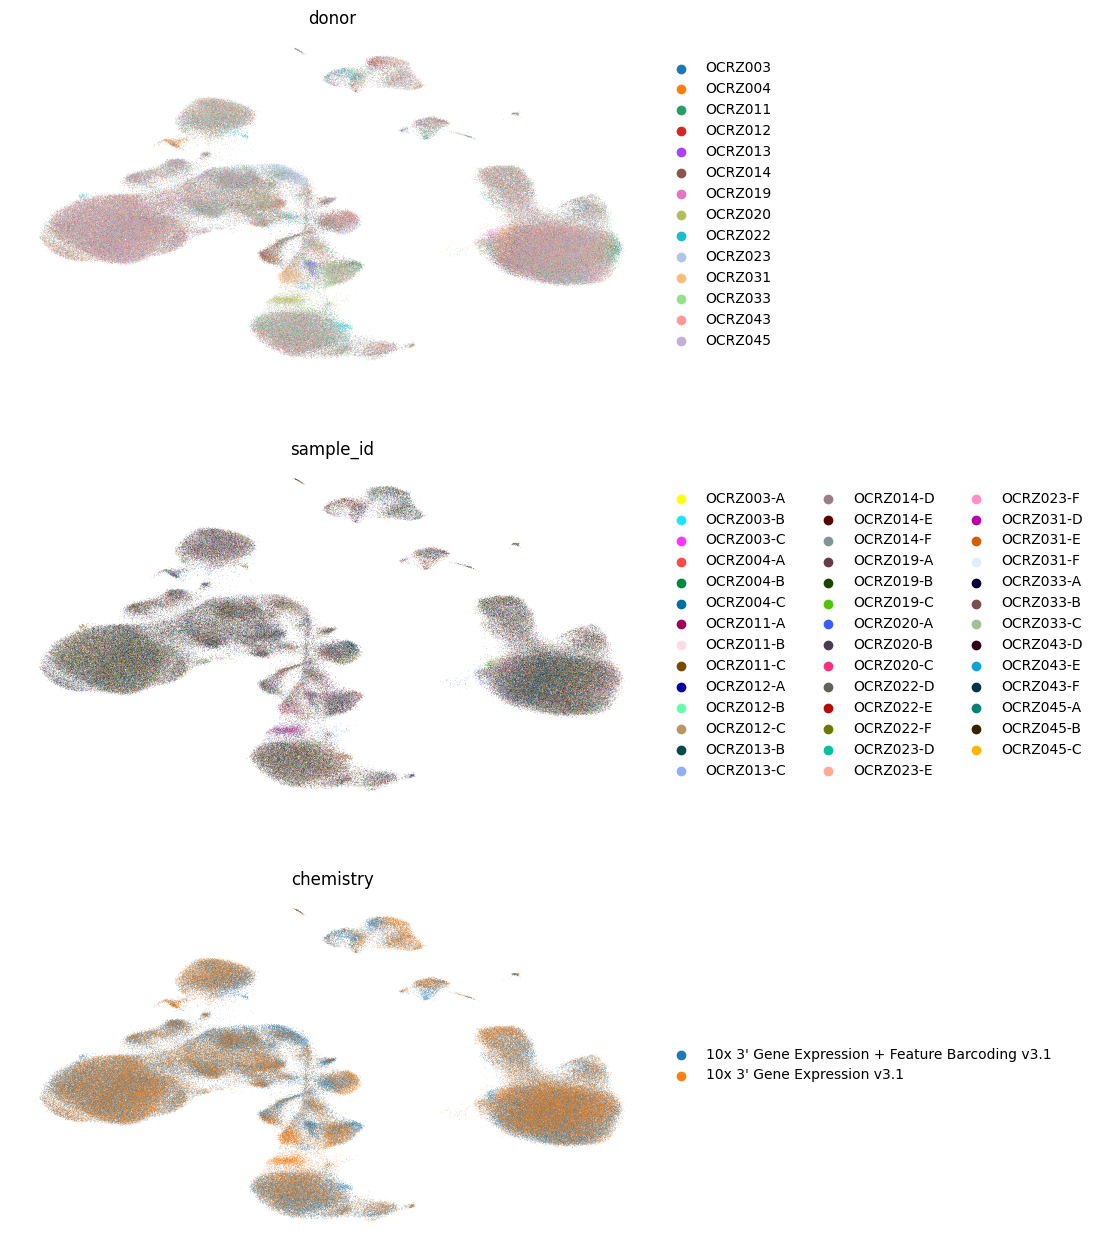

In [14]:
sc.pl.umap(
    mdata["rna"],
    color=["donor", "sample_id", "chemistry"],
    frameon=False,
    wspace=0.4,
    ncols=1,
)

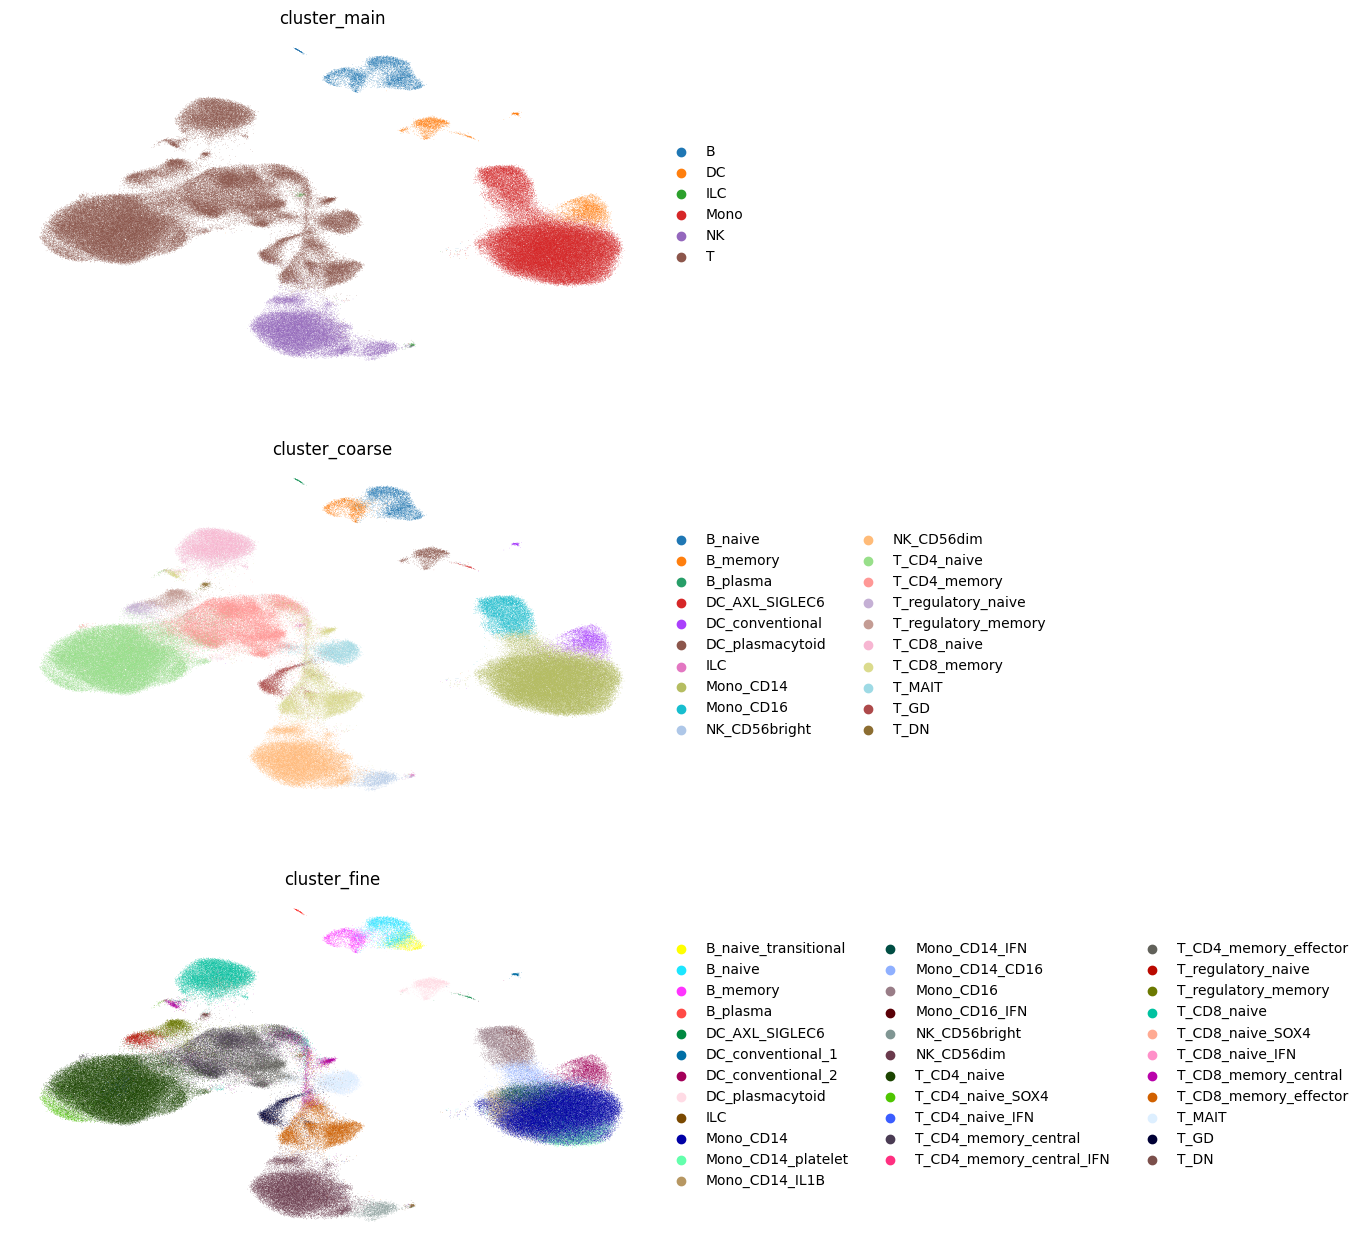

In [15]:
sc.pl.umap(
    mdata["rna"],
    color=["cluster_main", "cluster_coarse", "cluster_fine"],
    frameon=False,
    wspace=0.4,
    ncols=1,
)

In [ ]:
# Save the MuData object with denoised layers and latent embedding
mdata.write_h5mu(os.path.join(results_dir, "totalvi.h5mu"))

/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/python3.11/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/python3.11/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [7]:
mdata

MuData object with n_obs × n_vars = 264512 × 5153
  var:	'var.features', 'var.features.rank'
  2 modalities
    rna:	264512 x 4993
      obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample_id', 'hash_id', 'donor', 'processing_batch', 'experiment', 'chemistry', 'hto_panel', 'adt_panel', 'nCount_ADT', 'nFeature_ADT', 'pctMito_RNA', 'S.Score', 'G2M.Score', 'Phase', 'batch', 'cluster_main', 'cluster_coarse', 'cluster_fine'
      var:	'ensembl_id', 'gene_symbol', 'gene_type', 'vf_vst_counts.OCRZ003-A_mean', 'vf_vst_counts.OCRZ003-A_variance', 'vf_vst_counts.OCRZ003-A_variance.expected', 'vf_vst_counts.OCRZ003-A_variance.standardized', 'vf_vst_counts.OCRZ003-A_variable', 'vf_vst_counts.OCRZ003-A_rank', 'vf_vst_counts.OCRZ003-B_mean', 'vf_vst_counts.OCRZ003-B_variance', 'vf_vst_counts.OCRZ003-B_variance.expected', 'vf_vst_counts.OCRZ003-B_variance.standardized', 'vf_vst_counts.OCRZ003-B_variable', 'vf_vst_counts.OCRZ003-B_rank', 'vf_vst_counts.OCRZ003-C_mean', 'vf_vst_counts.OCRZ003-C_variance', 'vf_vst_counts.OCRZ003-C_variance.expected', 'vf_vst_counts.OCRZ003-C_variance.standardized', 'vf_vst_counts.OCRZ003-C_variable', 'vf_vst_counts.OCRZ003-C_rank', 'vf_vst_counts.OCRZ004-A_mean', 'vf_vst_counts.OCRZ004-A_variance', 'vf_vst_counts.OCRZ004-A_variance.expected', 'vf_vst_counts.OCRZ004-A_variance.standardized', 'vf_vst_counts.OCRZ004-A_variable', 'vf_vst_counts.OCRZ004-A_rank', 'vf_vst_counts.OCRZ004-B_mean', 'vf_vst_counts.OCRZ004-B_variance', 'vf_vst_counts.OCRZ004-B_variance.expected', 'vf_vst_counts.OCRZ004-B_variance.standardized', 'vf_vst_counts.OCRZ004-B_variable', 'vf_vst_counts.OCRZ004-B_rank', 'vf_vst_counts.OCRZ004-C_mean', 'vf_vst_counts.OCRZ004-C_variance', 'vf_vst_counts.OCRZ004-C_variance.expected', 'vf_vst_counts.OCRZ004-C_variance.standardized', 'vf_vst_counts.OCRZ004-C_variable', 'vf_vst_counts.OCRZ004-C_rank', 'vf_vst_counts.OCRZ011-A_mean', 'vf_vst_counts.OCRZ011-A_variance', 'vf_vst_counts.OCRZ011-A_variance.expected', 'vf_vst_counts.OCRZ011-A_variance.standardized', 'vf_vst_counts.OCRZ011-A_variable', 'vf_vst_counts.OCRZ011-A_rank', 'vf_vst_counts.OCRZ011-B_mean', 'vf_vst_counts.OCRZ011-B_variance', 'vf_vst_counts.OCRZ011-B_variance.expected', 'vf_vst_counts.OCRZ011-B_variance.standardized', 'vf_vst_counts.OCRZ011-B_variable', 'vf_vst_counts.OCRZ011-B_rank', 'vf_vst_counts.OCRZ011-C_mean', 'vf_vst_counts.OCRZ011-C_variance', 'vf_vst_counts.OCRZ011-C_variance.expected', 'vf_vst_counts.OCRZ011-C_variance.standardized', 'vf_vst_counts.OCRZ011-C_variable', 'vf_vst_counts.OCRZ011-C_rank', 'vf_vst_counts.OCRZ012-A_mean', 'vf_vst_counts.OCRZ012-A_variance', 'vf_vst_counts.OCRZ012-A_variance.expected', 'vf_vst_counts.OCRZ012-A_variance.standardized', 'vf_vst_counts.OCRZ012-A_variable', 'vf_vst_counts.OCRZ012-A_rank', 'vf_vst_counts.OCRZ012-B_mean', 'vf_vst_counts.OCRZ012-B_variance', 'vf_vst_counts.OCRZ012-B_variance.expected', 'vf_vst_counts.OCRZ012-B_variance.standardized', 'vf_vst_counts.OCRZ012-B_variable', 'vf_vst_counts.OCRZ012-B_rank', 'vf_vst_counts.OCRZ012-C_mean', 'vf_vst_counts.OCRZ012-C_variance', 'vf_vst_counts.OCRZ012-C_variance.expected', 'vf_vst_counts.OCRZ012-C_variance.standardized', 'vf_vst_counts.OCRZ012-C_variable', 'vf_vst_counts.OCRZ012-C_rank', 'vf_vst_counts.OCRZ013-B_mean', 'vf_vst_counts.OCRZ013-B_variance', 'vf_vst_counts.OCRZ013-B_variance.expected', 'vf_vst_counts.OCRZ013-B_variance.standardized', 'vf_vst_counts.OCRZ013-B_variable', 'vf_vst_counts.OCRZ013-B_rank', 'vf_vst_counts.OCRZ013-C_mean', 'vf_vst_counts.OCRZ013-C_variance', 'vf_vst_counts.OCRZ013-C_variance.expected', 'vf_vst_counts.OCRZ013-C_variance.standardized', 'vf_vst_counts.OCRZ013-C_variable', 'vf_vst_counts.OCRZ013-C_rank', 'vf_vst_counts.OCRZ014-D_mean', 'vf_vst_counts.OCRZ014-D_variance', 'vf_vst_counts.OCRZ014-D_variance.expected', 'vf_vst_counts.OCRZ014-D_variance.standardized', 'vf_vst_counts.OCRZ014-D_variable', 'vf_vst_counts.OCRZ014-D_rank', 'vf_vst_counts.OCRZ014-E_mean', 'vf_vst_counts.OCRZ014-E_variance', '

In [ ]:
# Save the AnnData RNA object with denoised counts and latent embedding
adata_rna = mdata["rna"].copy()
adata_rna.X = adata_rna.layers["denoised"]
adata_rna.write_h5ad(os.path.join(results_dir, "totalvi_rna_denoised.h5ad"))

In [ ]:
# Save the AnnData ADT object with denoised counts and latent embedding
adata_adt = mdata["adt"].copy()
adata_adt.X = adata_adt.layers["denoised"]
adata_adt.write_h5ad(os.path.join(results_dir, "totalvi_adt_denoised.h5ad"))

# Differential gene and protein expression between T~c~1-TH signature high vs low groups

In [ ]:
# Load AnnData object used to train TotalVI model
adata = ad.read_h5ad(os.path.join(results_dir, "adata.h5ad"))

In [ ]:
# Load gene program usage scores and compute Tc1-TH score
usage_df = pd.read_csv("../results/tables/cite_seq/cohort_treatment_naive/gep/T/finalised/usage.tsv", sep="\t", header=0, index_col=0)
program_score = usage_df["13"] + usage_df["20"] + usage_df["30"]

In [ ]:
# Threshold on composite Tc1-TH score and assign groups
threshold = 0.2 # threshold for high vs low program usage
adata.obs["group"] = pd.cut(
  program_score[adata.obs["cluster_coarse"][adata.obs["cluster_main"] == "T"].isin(["T_CD4_memory", "T_CD8_memory"])],
  bins=[-np.inf, threshold, np.inf],
  labels=["Tc1-TH low", "Tc1-TH high"]
)

In [9]:
de_df = model.differential_expression(
    adata,
    groupby="group",
    group1="Tc1-TH high",
    group2="Tc1-TH low",
    mode="change",
    delta=0.1,
    include_protein_background=False,
    batch_correction=True,
    fdr_target=0.05,
    all_stats=False,
)

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     Found batches with missing protein expression                                                             


DE...:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
with pd.ExcelWriter("../results/tables/cite_seq/cohort_treatment_naive/totalvi_markers.xlsx") as writer:
    # Gene markers
    de_df[~de_df.index.str.startswith("ADT-") & (de_df["lfc_mean"] > 0)].sort_values("bayes_factor", ascending=False).to_excel(
        writer,
        sheet_name="Gene",
        header=True,
        index=True,
    )
    # Protein markers
    de_df[de_df.index.str.startswith("ADT-") & (de_df["lfc_mean"] > 0)].sort_values("bayes_factor", ascending=False).to_excel(
        writer,
        sheet_name="Protein",
        header=True,
        index=True,
    )